# Week 3
## 1.Work flow Continue

In [1]:
#2026-5-16
# This block is to import the result and workflow last time.
import numpy as np
import pandas as pd
from scipy.fftpack import dct, idct
# RERUN NOTE: Rerun after 2.ipynb rebuilds compression_eval_results.npy. This cell loads the old-vs-new compression evaluation cache.
from pathlib import Path
import matplotlib.pyplot as plt
from kilosort.io import load_ops

SAVE_PATH = Path('F:\\ACADEMIC') / '.test_data' / 'ZFM-02370_mini.imec0.ap.short.bin'

n_chan = 385          # channel number
N = 267 # Neuron Number
dtype = 'int16'

# Load the saved Sorting results from the local drive.
results_dir = SAVE_PATH.parent / 'kilosort4'
ops = load_ops(results_dir / 'ops.npy')
camps = pd.read_csv(results_dir / 'cluster_Amplitude.tsv', sep='\t')['Amplitude'].values
contam_pct = pd.read_csv(results_dir / 'cluster_ContamPct.tsv', sep='\t')['ContamPct'].values
chan_map =  np.load(results_dir / 'channel_map.npy')
templates =  np.load(results_dir / 'templates.npy')
chan_best = (templates**2).sum(axis=1).argmax(axis=-1)
chan_best = chan_map[chan_best]
amplitudes = np.load(results_dir / 'amplitudes.npy')
st = np.load(results_dir / 'spike_times.npy')
clu = np.load(results_dir / 'spike_clusters.npy')

fs = ops['fs']
firing_rates = np.unique(clu, return_counts=True)[1] * fs / st.max()
dshift = ops['dshift']

In [13]:
# RERUN NOTE: Rerun after 2.ipynb regenerates whitened_data.npy with CAR. Any analysis that uses this file depends on the updated preprocessing.
# Memory note: use mmap_mode='r' so we do not materialize the full ~2 GiB array just to inspect shape or slice small regions.
whitened_data = np.load('whitened_data.npy', mmap_mode='r')  # shape: (n_samples, n_channels)
n_samples, n_channels = whitened_data.shape
print(f"Shape: {n_samples} Samples × {n_channels} Channels")

Shape: 1350000 Samples × 385 Channels


## 2. Baseline-Anchored Spike Labeling (No Hungarian Remapping)
This section evaluates compressed-data sorting using a strict baseline reference.

For each spike detected in compressed data, we find the nearest baseline spike in time.
If the time difference is within a tolerance window, the compressed spike inherits the baseline cluster label directly.
Unmatched spikes are assigned label `-1`.

This avoids cluster-to-cluster remapping and keeps baseline cluster identity as the only ground truth.

The matching directions are different:

- 2.0: baseline -> nearest test (find the nearest test spike for each baseline spike)

- 3's nearest: test -> nearest baseline (find the nearest baseline spike for each test spike)

In [14]:
from pathlib import Path
import numpy as np


def extract_spike_times_1d(st_array):
    st = np.asarray(st_array)
    if st.ndim == 1:
        return st.astype(np.int64, copy=False)
    if st.ndim >= 2:
        return st[:, 0].astype(np.int64, copy=False)
    raise ValueError(f'Unsupported st shape: {st.shape}')


def list_available_kilosort_ratios(root=Path('.')):
    ratios = []
    for p in sorted(root.glob('ks_recon_ratio_*')):
        try:
            ratio = float(p.name.split('_')[-1])
        except Exception:
            continue
        has_spike_outputs = (p / 'spike_times.npy').exists() and (p / 'spike_clusters.npy').exists()
        if has_spike_outputs:
            ratios.append(ratio)
    return ratios


def load_ratio_spike_outputs(ratio, root=Path('.')):
    ratio_dir = root / f'ks_recon_ratio_{ratio:.2f}'
    spike_times_path = ratio_dir / 'spike_times.npy'
    spike_clusters_path = ratio_dir / 'spike_clusters.npy'
    if not spike_times_path.exists() or not spike_clusters_path.exists():
        raise FileNotFoundError(
            f'Missing Kilosort spike outputs for ratio={ratio:.2f}: {ratio_dir}'
        )
    return {
        'st': np.load(spike_times_path, mmap_mode='r'),
        'clu': np.load(spike_clusters_path, mmap_mode='r'),
    }


baseline_res = np.load('baseline_results.npy', allow_pickle=True).item()
available_ratios = list_available_kilosort_ratios()

baseline_st = extract_spike_times_1d(baseline_res['st'])
baseline_clu = np.asarray(baseline_res['clu']).astype(np.int64)

print(f'Baseline spikes: {len(baseline_st)}')
print(f'Baseline clusters: {len(np.unique(baseline_clu))}')
print(f'Available ratios from ks_recon_ratio_*/spike_times.npy: {available_ratios}')



Baseline spikes: 137381
Baseline clusters: 267
Available ratios from ks_recon_ratio_*/spike_times.npy: [0.1, 0.2]


In [15]:
def assign_to_baseline_clusters(baseline_st, baseline_clu, test_st, tolerance=30):
    # Nearest-neighbor anchoring (test -> baseline), not one-to-one.
    baseline_st = np.asarray(baseline_st, dtype=np.int64)
    baseline_clu = np.asarray(baseline_clu, dtype=np.int64)
    test_st = np.asarray(test_st, dtype=np.int64)

    labels = np.full(test_st.shape[0], -1, dtype=np.int64)
    matched_baseline_idx = np.full(test_st.shape[0], -1, dtype=np.int64)
    time_error = np.full(test_st.shape[0], np.nan, dtype=np.float32)

    if baseline_st.size == 0 or test_st.size == 0:
        return labels, matched_baseline_idx, time_error

    pos = np.searchsorted(baseline_st, test_st)
    left = np.clip(pos - 1, 0, baseline_st.size - 1)
    right = np.clip(pos, 0, baseline_st.size - 1)

    dt_left = np.abs(test_st - baseline_st[left])
    dt_right = np.abs(test_st - baseline_st[right])

    use_left = dt_left <= dt_right
    nearest_idx = np.where(use_left, left, right)
    nearest_dt = np.where(use_left, dt_left, dt_right)

    ok = nearest_dt <= tolerance
    matched_baseline_idx[ok] = nearest_idx[ok]
    labels[ok] = baseline_clu[nearest_idx[ok]]
    time_error[ok] = nearest_dt[ok].astype(np.float32)

    return labels, matched_baseline_idx, time_error


def assign_to_baseline_clusters_mutual_1to1(baseline_st, baseline_clu, test_st, tolerance=30):
    # Mutual nearest-neighbor anchoring with one-to-one constraint.
    baseline_st = np.asarray(baseline_st, dtype=np.int64)
    baseline_clu = np.asarray(baseline_clu, dtype=np.int64)
    test_st = np.asarray(test_st, dtype=np.int64)

    n_base = baseline_st.size
    n_test = test_st.size

    labels = np.full(n_test, -1, dtype=np.int64)
    matched_baseline_idx = np.full(n_test, -1, dtype=np.int64)
    time_error = np.full(n_test, np.nan, dtype=np.float32)

    if n_base == 0 or n_test == 0:
        return labels, matched_baseline_idx, time_error

    # test -> nearest base
    pos_tb = np.searchsorted(baseline_st, test_st)
    left_tb = np.clip(pos_tb - 1, 0, n_base - 1)
    right_tb = np.clip(pos_tb, 0, n_base - 1)
    dt_left_tb = np.abs(test_st - baseline_st[left_tb])
    dt_right_tb = np.abs(test_st - baseline_st[right_tb])
    use_left_tb = dt_left_tb <= dt_right_tb
    nn_base_for_test = np.where(use_left_tb, left_tb, right_tb)
    nn_dt_for_test = np.where(use_left_tb, dt_left_tb, dt_right_tb)

    # base -> nearest test
    pos_bt = np.searchsorted(test_st, baseline_st)
    left_bt = np.clip(pos_bt - 1, 0, n_test - 1)
    right_bt = np.clip(pos_bt, 0, n_test - 1)
    dt_left_bt = np.abs(baseline_st - test_st[left_bt])
    dt_right_bt = np.abs(baseline_st - test_st[right_bt])
    use_left_bt = dt_left_bt <= dt_right_bt
    nn_test_for_base = np.where(use_left_bt, left_bt, right_bt)

    # mutual nearest + tolerance
    test_idx = np.arange(n_test, dtype=np.int64)
    b_idx = nn_base_for_test
    mutual = nn_test_for_base[b_idx] == test_idx
    ok = mutual & (nn_dt_for_test <= tolerance)

    matched_baseline_idx[ok] = b_idx[ok]
    labels[ok] = baseline_clu[b_idx[ok]]
    time_error[ok] = nn_dt_for_test[ok].astype(np.float32)

    return labels, matched_baseline_idx, time_error


def summarize_baseline_anchored(baseline_clu, assigned_labels):
    assigned_labels = np.asarray(assigned_labels)
    matched = assigned_labels >= 0
    matched_rate = float(np.mean(matched)) if assigned_labels.size else 0.0

    unique_base = np.unique(baseline_clu)
    per_cluster_count = {}
    for cid in unique_base:
        per_cluster_count[int(cid)] = int(np.sum(assigned_labels == cid))

    return {
        'matched_rate_on_test_spikes': matched_rate,
        'n_test_spikes': int(assigned_labels.size),
        'n_matched_test_spikes': int(np.sum(matched)),
        'n_unmatched_test_spikes': int(np.sum(~matched)),
        'n_baseline_clusters_covered': int(np.sum(np.array(list(per_cluster_count.values())) > 0)),
        'per_baseline_cluster_assigned_count': per_cluster_count,
    }


def cluster_classification_accuracy_hungarian(y_true_baseline, y_pred_test):
    from scipy.optimize import linear_sum_assignment

    y_true = np.asarray(y_true_baseline, dtype=np.int64)
    y_pred = np.asarray(y_pred_test, dtype=np.int64)

    if y_true.size == 0:
        return 0.0, np.zeros((0, 0), dtype=np.int64)

    true_ids = np.unique(y_true)
    pred_ids = np.unique(y_pred)
    true_to_i = {c: i for i, c in enumerate(true_ids)}
    pred_to_j = {c: j for j, c in enumerate(pred_ids)}

    C = np.zeros((len(true_ids), len(pred_ids)), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        C[true_to_i[t], pred_to_j[p]] += 1

    r, c = linear_sum_assignment(-C)
    correct = C[r, c].sum()
    acc = float(correct / max(C.sum(), 1))
    return acc, C



In [16]:
# Memory note: read only spike_times.npy and spike_clusters.npy from each ratio directory.
tolerance = 30
anchored_results = {}

for ratio in available_ratios:
    ks_spikes = load_ratio_spike_outputs(ratio)
    test_st = extract_spike_times_1d(ks_spikes['st'])
    test_clu = np.asarray(ks_spikes['clu']).astype(np.int64)

    # A) nearest (original)
    labels_a, idx_a, err_a = assign_to_baseline_clusters(
        baseline_st=baseline_st,
        baseline_clu=baseline_clu,
        test_st=test_st,
        tolerance=tolerance,
    )
    sum_a = summarize_baseline_anchored(baseline_clu, labels_a)
    mask_a = labels_a >= 0
    acc_a, conf_a = cluster_classification_accuracy_hungarian(labels_a[mask_a], test_clu[mask_a])

    # B) mutual nearest 1-to-1 (new)
    labels_b, idx_b, err_b = assign_to_baseline_clusters_mutual_1to1(
        baseline_st=baseline_st,
        baseline_clu=baseline_clu,
        test_st=test_st,
        tolerance=tolerance,
    )
    sum_b = summarize_baseline_anchored(baseline_clu, labels_b)
    mask_b = labels_b >= 0
    acc_b, conf_b = cluster_classification_accuracy_hungarian(labels_b[mask_b], test_clu[mask_b])

    anchored_results[ratio] = {
        'ratio': float(ratio),
        'tolerance_samples': int(tolerance),
        'test_st': test_st,
        'test_clu': test_clu,
        'nearest': {
            'assigned_baseline_clu': labels_a,
            'matched_baseline_idx': idx_a,
            'time_error_samples': err_a,
            'cluster_confusion_matched': conf_a,
            'cluster_classification_accuracy_hungarian': acc_a,
            'summary': sum_a,
        },
        'mutual_1to1': {
            'assigned_baseline_clu': labels_b,
            'matched_baseline_idx': idx_b,
            'time_error_samples': err_b,
            'cluster_confusion_matched': conf_b,
            'cluster_classification_accuracy_hungarian': acc_b,
            'summary': sum_b,
        },
    }

    print('\n' + '=' * 72)
    print(f'ratio={ratio:.2f}')
    print('[nearest]')
    print(f"  matched(test->baseline): {sum_a['n_matched_test_spikes']}/{sum_a['n_test_spikes']} ({sum_a['matched_rate_on_test_spikes']:.4f})")
    print(f"  baseline clusters covered: {sum_a['n_baseline_clusters_covered']}/{len(np.unique(baseline_clu))}")
    print(f"  cluster cls acc (Hungarian): {acc_a:.4f}")

    print('[mutual_1to1]')
    print(f"  matched(test->baseline): {sum_b['n_matched_test_spikes']}/{sum_b['n_test_spikes']} ({sum_b['matched_rate_on_test_spikes']:.4f})")
    print(f"  baseline clusters covered: {sum_b['n_baseline_clusters_covered']}/{len(np.unique(baseline_clu))}")
    print(f"  cluster cls acc (Hungarian): {acc_b:.4f}")

np.save('baseline_anchored_results.npy', anchored_results, allow_pickle=True)
print('\nSaved: baseline_anchored_results.npy')




ratio=0.10
[nearest]
  matched(test->baseline): 470368/473146 (0.9941)
  baseline clusters covered: 267/267
  cluster cls acc (Hungarian): 0.1315
[mutual_1to1]
  matched(test->baseline): 112238/473146 (0.2372)
  baseline clusters covered: 267/267
  cluster cls acc (Hungarian): 0.2916

ratio=0.20
[nearest]
  matched(test->baseline): 207921/208427 (0.9976)
  baseline clusters covered: 267/267
  cluster cls acc (Hungarian): 0.3996
[mutual_1to1]
  matched(test->baseline): 109535/208427 (0.5255)
  baseline clusters covered: 267/267
  cluster cls acc (Hungarian): 0.6196

Saved: baseline_anchored_results.npy


## Notes:
### matched(test->baseline)

Meaning: Of the test spikes detected after compression, how many match the baseline spikes in time (within tolerance).

Essence: Detection layer metric (whether an event was found).

Does not consider whether the cluster classification is correct.

### cluster cls acc (Hungarian)

Meaning: Among the "matched spikes," compare the test_clu with the baseline reference label, and after Hungarian optimal mapping, the proportion of correctly classified spikes.

Essence: Identity layer metric (whether the event correctly belongs to which neuron).

# Side-by-side comparison table for nearest vs mutual_1to1
Mutual 1to1 Process:

1. First, perform test -> nearest baseline.

- For each test spike, find the nearest baseline spike (most recent in time).

2. Then, perform baseline -> nearest test.

- For each baseline spike, find the nearest test spike in reverse order.

3. Select "mutual nearest neighbors".

- Only retain a pair if the nearest neighbor of test_j is base_i, and the nearest neighbor of base_i is also test_j.

4. Add tolerance constraints.

- Also satisfy |t_test - t_base| <= tolerance (for your current 30 samples).

5. Assign labels.

- Only test spikes that pass the above selection inherit the baseline cluster; others are marked with -1.

Difference from nearest:

- nearest (your current one-way version)

Only performs test -> nearest baseline.

Multiple test spikes may match the same baseline spike (many-to-one), making it more "lenient". - mutual_1to1

Requires both sides to be closest, naturally one-to-one, more "strict".



## 3. Objective Time-Matching Evaluation (Event-Level, No Cluster Mapping)
The "time difference" only tells you how much difference there is between two points; it doesn't resolve the conflict of "how to allocate a global one-to-one baseline." For example, choosing the nearest baseline for every test can lead to many-to-one relationships (many tests competing for the same baseline). In more complex and dense scenarios, securing a seemingly optimal edge first might worsen many subsequent edges; that is, local optimum does not equal global optimum.

Hungarian algorithms solve this global combinatorial problem: simultaneously satisfying the one-to-one constraint (each test/base can only be used once), they consider the global context at once, finding the solution with the minimum sum.

This section evaluates event-time detection quality using four matching methods.
For fair ranking, prioritize strict one-to-one methods (`mutual_1to1`, `optimal_1to1`, `hungarian_time_1to1`).

In [17]:
def detection_metrics_from_assignment(matched_baseline_idx, n_baseline, n_test):
    """
    Objective event-detection metrics from time matching.
    Primary metrics:
    - Dice(F1_overlap) = 2TP / (N_test + N_base)
    - Jaccard = TP / (N_test + N_base - TP)
    - Precision = TP / N_test
    - Recall = TP / N_base
    Error metrics:
    - Miss rate = 1 - Recall
    - FDR = 1 - Precision
    """
    idx = np.asarray(matched_baseline_idx, dtype=np.int64)
    matched_mask = idx >= 0

    tp_test = int(np.sum(matched_mask))
    unique_base = np.unique(idx[matched_mask]) if tp_test > 0 else np.array([], dtype=np.int64)
    tp_base_unique = int(unique_base.size)
    tp = min(tp_test, tp_base_unique) if tp_base_unique > 0 else tp_test

    n_test = int(n_test)
    n_baseline = int(n_baseline)

    precision = tp / max(n_test, 1)
    recall = tp / max(n_baseline, 1)
    dice = (2 * tp) / max(n_test + n_baseline, 1)
    jaccard = tp / max(n_test + n_baseline - tp, 1)
    miss_rate = 1.0 - recall
    fdr = 1.0 - precision

    return {
        'TP': int(tp),
        'TP_test': int(tp_test),
        'TP_base_unique': int(tp_base_unique),
        'n_test': n_test,
        'n_baseline': n_baseline,
        'precision': float(precision),
        'recall': float(recall),
        'dice_f1_overlap': float(dice),
        'jaccard': float(jaccard),
        'miss_rate': float(miss_rate),
        'fdr': float(fdr),
    }


def time_error_stats(time_error_samples):
    e = np.asarray(time_error_samples, dtype=np.float64)
    e = e[np.isfinite(e)]
    if e.size == 0:
        return {'n': 0, 'median': np.nan, 'p95': np.nan, 'mean': np.nan}
    return {
        'n': int(e.size),
        'median': float(np.median(e)),
        'p95': float(np.percentile(e, 95)),
        'mean': float(np.mean(e)),
    }


def assign_to_baseline_clusters_optimal_1to1(baseline_st, baseline_clu, test_st, tolerance=30):
    baseline_st = np.asarray(baseline_st, dtype=np.int64)
    baseline_clu = np.asarray(baseline_clu, dtype=np.int64)
    test_st = np.asarray(test_st, dtype=np.int64)

    n_base = baseline_st.size
    n_test = test_st.size

    labels = np.full(n_test, -1, dtype=np.int64)
    matched_baseline_idx = np.full(n_test, -1, dtype=np.int64)
    time_error = np.full(n_test, np.nan, dtype=np.float32)

    if n_base == 0 or n_test == 0:
        return labels, matched_baseline_idx, time_error

    pos = np.searchsorted(baseline_st, test_st)
    left = np.clip(pos - 1, 0, n_base - 1)
    right = np.clip(pos, 0, n_base - 1)

    edges = []
    for j in range(n_test):
        for i in (left[j], right[j]):
            dt = abs(int(test_st[j]) - int(baseline_st[i]))
            if dt <= tolerance:
                edges.append((dt, j, int(i)))

    if not edges:
        return labels, matched_baseline_idx, time_error

    edges.sort(key=lambda x: x[0])
    used_test = np.zeros(n_test, dtype=bool)
    used_base = np.zeros(n_base, dtype=bool)

    for dt, j, i in edges:
        if (not used_test[j]) and (not used_base[i]):
            used_test[j] = True
            used_base[i] = True
            matched_baseline_idx[j] = i
            labels[j] = baseline_clu[i]
            time_error[j] = float(dt)

    return labels, matched_baseline_idx, time_error


def assign_to_baseline_clusters_hungarian_time(
    baseline_st,
    baseline_clu,
    test_st,
    tolerance=30,
    max_block_spikes=3000,
    max_pairwise_entries=250000,
    row_chunk_size=256,
):
    from scipy.optimize import linear_sum_assignment

    baseline_st = np.asarray(baseline_st, dtype=np.int64)
    baseline_clu = np.asarray(baseline_clu, dtype=np.int64)
    test_st = np.asarray(test_st, dtype=np.int64)

    n_base = baseline_st.size
    n_test = test_st.size

    labels = np.full(n_test, -1, dtype=np.int64)
    matched_baseline_idx = np.full(n_test, -1, dtype=np.int64)
    time_error = np.full(n_test, np.nan, dtype=np.float32)

    if n_base == 0 or n_test == 0:
        return labels, matched_baseline_idx, time_error

    order_test = np.argsort(test_st)
    test_sorted = test_st[order_test]
    BIG = np.float32(tolerance + 1e6)

    start = 0
    while start < n_test:
        end = min(start + max_block_spikes, n_test)

        while True:
            t_block = test_sorted[start:end]
            tmin = int(t_block[0] - tolerance)
            tmax = int(t_block[-1] + tolerance)
            b0 = int(np.searchsorted(baseline_st, tmin, side='left'))
            b1 = int(np.searchsorted(baseline_st, tmax, side='right'))
            m_try = end - start
            n_try = max(b1 - b0, 1)
            if m_try <= 1 or (m_try * n_try) <= max_pairwise_entries:
                break
            end = start + max(1, m_try // 2)

        if b1 <= b0:
            start = end
            continue

        base_idx_block = np.arange(b0, b1, dtype=np.int64)
        base_block = baseline_st[base_idx_block]

        m = t_block.size
        n = base_block.size
        dim = max(m, n)
        C = np.full((dim, dim), BIG, dtype=np.float32)

        for row0 in range(0, m, row_chunk_size):
            row1 = min(row0 + row_chunk_size, m)
            dt_chunk = np.abs(
                t_block[row0:row1, None].astype(np.int64) - base_block[None, :].astype(np.int64)
            )
            valid_chunk = dt_chunk <= tolerance
            if np.any(valid_chunk):
                C[row0:row1, :n][valid_chunk] = dt_chunk[valid_chunk].astype(np.float32)

        r, c = linear_sum_assignment(C)
        for rr, cc in zip(r, c):
            if rr < m and cc < n:
                cost = C[rr, cc]
                if cost <= tolerance:
                    j_sorted = start + rr
                    j_orig = int(order_test[j_sorted])
                    bi = int(base_idx_block[cc])
                    if matched_baseline_idx[j_orig] < 0:
                        matched_baseline_idx[j_orig] = bi
                        labels[j_orig] = baseline_clu[bi]
                        time_error[j_orig] = float(cost)

        start = end

    return labels, matched_baseline_idx, time_error



In [19]:
# RERUN NOTE: Rerun after the Kilosort ratio directories are refreshed. These detection metrics are invalid if they still point to pre-CAR reconstruction results.
# Memory note: do not load large pickled result bundles; read per-ratio spike arrays directly.
# Evaluate objective detection metrics

detection_eval = {}
tolerance = 30

for ratio in available_ratios:
    ks_spikes = load_ratio_spike_outputs(ratio)
    test_st = extract_spike_times_1d(ks_spikes['st'])

    _, idx_a, err_a = assign_to_baseline_clusters(baseline_st, baseline_clu, test_st, tolerance=tolerance)
    m_a = detection_metrics_from_assignment(idx_a, len(baseline_st), len(test_st))
    e_a = time_error_stats(err_a)

    _, idx_b, err_b = assign_to_baseline_clusters_mutual_1to1(baseline_st, baseline_clu, test_st, tolerance=tolerance)
    m_b = detection_metrics_from_assignment(idx_b, len(baseline_st), len(test_st))
    e_b = time_error_stats(err_b)

    _, idx_c, err_c = assign_to_baseline_clusters_optimal_1to1(baseline_st, baseline_clu, test_st, tolerance=tolerance)
    m_c = detection_metrics_from_assignment(idx_c, len(baseline_st), len(test_st))
    e_c = time_error_stats(err_c)

    _, idx_d, err_d = assign_to_baseline_clusters_hungarian_time(baseline_st, baseline_clu, test_st, tolerance=tolerance, max_block_spikes=3000)
    m_d = detection_metrics_from_assignment(idx_d, len(baseline_st), len(test_st))
    e_d = time_error_stats(err_d)

    detection_eval[ratio] = {
        'nearest': {'metrics': m_a, 'time_error': e_a},
        'mutual_1to1': {'metrics': m_b, 'time_error': e_b},
        'optimal_1to1': {'metrics': m_c, 'time_error': e_c},
        'hungarian_time_1to1': {'metrics': m_d, 'time_error': e_d},
    }

    print('\n' + '=' * 96)
    print(f'ratio={float(ratio):.2f} | tolerance={tolerance} samples')

    def _show(name, m, e):
        print(f'[{name}]')
        print(f"  Dice(F1_overlap)=2TP/(N_test+N_base)={m['dice_f1_overlap']:.4f} | Jaccard=TP/(N_test+N_base-TP)={m['jaccard']:.4f}")
        print(f"  Precision=TP/N_test={m['precision']:.4f} | Recall=TP/N_base={m['recall']:.4f}")
        print(f"  Miss rate=1-Recall={m['miss_rate']:.4f} | FDR=1-Precision={m['fdr']:.4f}")
        print(f"  TP={m['TP']}, N_test={m['n_test']}, N_base={m['n_baseline']}")
        print(f"  |dt| samples: median={e['median']:.2f}, p95={e['p95']:.2f}, mean={e['mean']:.2f}")

    _show('nearest (reference, many-to-one)', m_a, e_a)
    _show('mutual_1to1', m_b, e_b)
    _show('optimal_1to1 (greedy min-|dt|)', m_c, e_c)
    _show('hungarian_time_1to1 (blockwise min-cost)', m_d, e_d)

np.save('detection_time_matching_eval.npy', detection_eval, allow_pickle=True)
print('\nSaved: detection_time_matching_eval.npy')




ratio=0.10 | tolerance=30 samples
[nearest (reference, many-to-one)]
  Dice(F1_overlap)=2TP/(N_test+N_base)=0.4129 | Jaccard=TP/(N_test+N_base-TP)=0.2602
  Precision=TP/N_test=0.2664 | Recall=TP/N_base=0.9175
  Miss rate=1-Recall=0.0825 | FDR=1-Precision=0.7336
  TP=126041, N_test=473146, N_base=137381
  |dt| samples: median=2.00, p95=14.00, mean=3.98
[mutual_1to1]
  Dice(F1_overlap)=2TP/(N_test+N_base)=0.3677 | Jaccard=TP/(N_test+N_base-TP)=0.2252
  Precision=TP/N_test=0.2372 | Recall=TP/N_base=0.8170
  Miss rate=1-Recall=0.1830 | FDR=1-Precision=0.7628
  TP=112238, N_test=473146, N_base=137381
  |dt| samples: median=0.00, p95=2.00, mean=0.65
[optimal_1to1 (greedy min-|dt|)]
  Dice(F1_overlap)=2TP/(N_test+N_base)=0.4316 | Jaccard=TP/(N_test+N_base-TP)=0.2752
  Precision=TP/N_test=0.2785 | Recall=TP/N_base=0.9591
  Miss rate=1-Recall=0.0409 | FDR=1-Precision=0.7215
  TP=131766, N_test=473146, N_base=137381
  |dt| samples: median=1.00, p95=3.00, mean=0.92
[hungarian_time_1to1 (blockwis

### Hungarian Time-Edge Matching (English)
Hungarian is used here for event-time pairing, not cluster-label mapping.
We match test spikes to baseline spikes with one-to-one minimum-cost assignment using `|dt|` as cost.
For large data, matching is solved blockwise in time for tractable runtime and memory.

Better: Dice/F1_overlap⬆️,Jaccard⬆️,Miss rate⬇️,False discovery rate⬇️

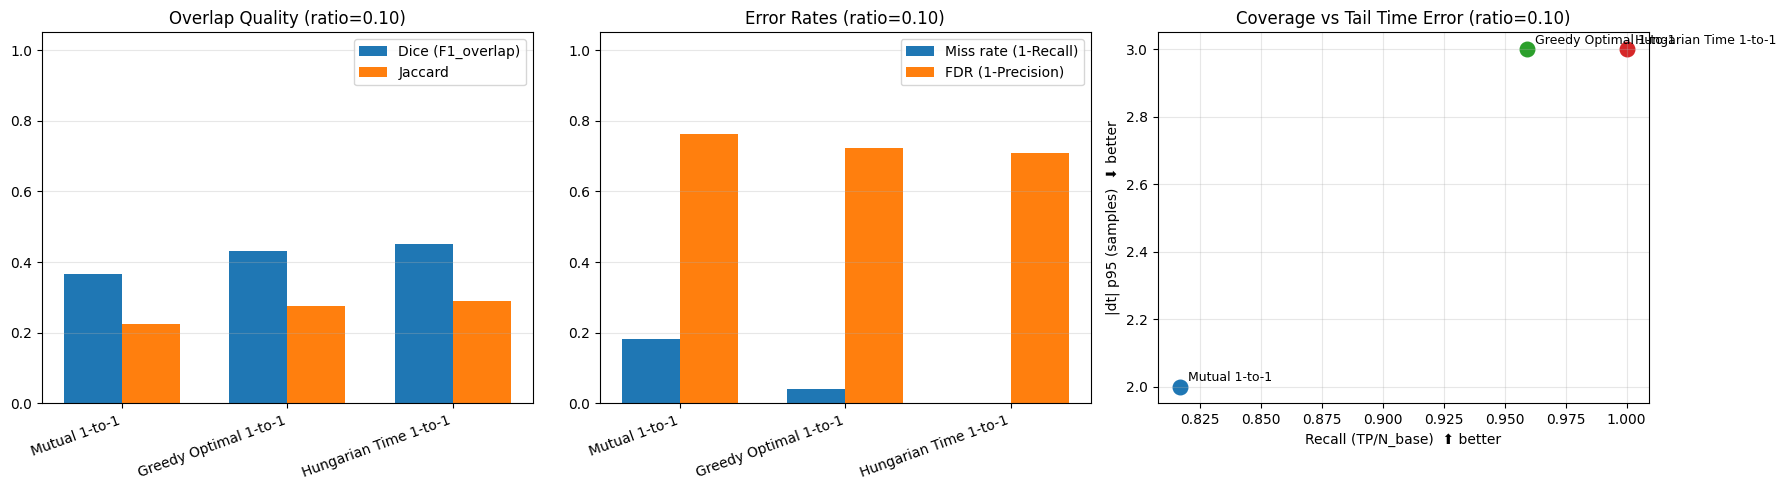

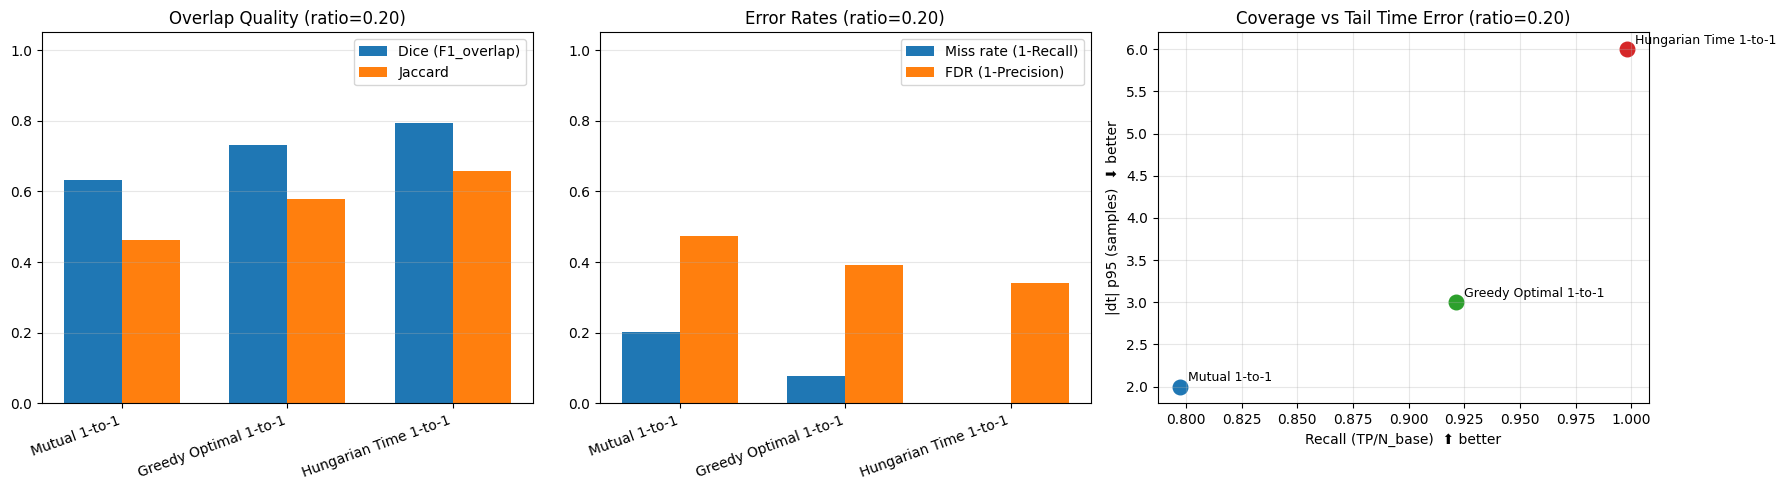

Reference-only (not strict comparable): nearest many-to-one
ratio=0.10 | Dice=0.4129, Jaccard=0.2602, Miss=0.0825, FDR=0.7336, p95=14.00
ratio=0.20 | Dice=0.6907, Jaccard=0.5275, Miss=0.1307, FDR=0.4270, p95=10.00


In [20]:
# Objective visualization focused on strict one-to-one comparability
import numpy as np
import matplotlib.pyplot as plt

if 'detection_eval' not in globals() or len(detection_eval) == 0:
    detection_eval = np.load('detection_time_matching_eval.npy', allow_pickle=True).item()

ratios = sorted(detection_eval.keys())
one_to_one_methods = ['mutual_1to1', 'optimal_1to1', 'hungarian_time_1to1']
label = {
    'mutual_1to1': 'Mutual 1-to-1',
    'optimal_1to1': 'Greedy Optimal 1-to-1',
    'hungarian_time_1to1': 'Hungarian Time 1-to-1',
}
color = {
    'mutual_1to1': '#1f77b4',
    'optimal_1to1': '#2ca02c',
    'hungarian_time_1to1': '#d62728',
}

for ratio in ratios:
    d = detection_eval[ratio]
    x = np.arange(len(one_to_one_methods))
    names = [label[m] for m in one_to_one_methods]

    dice = [d[m]['metrics']['dice_f1_overlap'] for m in one_to_one_methods]
    jacc = [d[m]['metrics']['jaccard'] for m in one_to_one_methods]
    miss = [d[m]['metrics']['miss_rate'] for m in one_to_one_methods]
    fdr = [d[m]['metrics']['fdr'] for m in one_to_one_methods]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    w = 0.35
    axes[0].bar(x - w/2, dice, width=w, label='Dice (F1_overlap)')
    axes[0].bar(x + w/2, jacc, width=w, label='Jaccard')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(names, rotation=20, ha='right')
    axes[0].set_ylim(0, 1.05)
    axes[0].set_title(f'Overlap Quality (ratio={ratio:.2f})')
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].legend()

    axes[1].bar(x - w/2, miss, width=w, label='Miss rate (1-Recall)')
    axes[1].bar(x + w/2, fdr, width=w, label='FDR (1-Precision)')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(names, rotation=20, ha='right')
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title(f'Error Rates (ratio={ratio:.2f})')
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].legend()

    for m in one_to_one_methods:
        rec = d[m]['metrics']['recall']
        p95v = d[m]['time_error']['p95']
        axes[2].scatter(rec, p95v, s=110, color=color[m], label=label[m])
        axes[2].annotate(label[m], (rec, p95v), textcoords='offset points', xytext=(6,4), fontsize=9)
    axes[2].set_xlabel('Recall (TP/N_base)  ⬆️ better')
    axes[2].set_ylabel('|dt| p95 (samples)  ⬇️ better')
    axes[2].set_title(f'Coverage vs Tail Time Error (ratio={ratio:.2f})')
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

print('Reference-only (not strict comparable): nearest many-to-one')
for ratio in ratios:
    m = detection_eval[ratio]['nearest']['metrics']
    e = detection_eval[ratio]['nearest']['time_error']
    print(f"ratio={ratio:.2f} | Dice={m['dice_f1_overlap']:.4f}, Jaccard={m['jaccard']:.4f}, Miss={m['miss_rate']:.4f}, FDR={m['fdr']:.4f}, p95={e['p95']:.2f}")



p95 Definition:
- Sort all matching pairs by their |dt| (absolute time error) from smallest to largest.
- Take the 95th percentile value.
- Meaning: 95% of the matching errors do not exceed this value, and the worst 5% are above it.

Why it reflects "local robustness" (more accurately, "tail robustness"):

- The mean is averaged across the whole, and a small number of bad points may be diluted.
- The median only considers the middle, ignoring bad examples at the tail.
- p95 specifically targets the "small segment close to the worst" (top 5% error).

Therefore:

- If p95 is high, it means that some matching errors are significantly larger in certain local areas (certain time periods/certain dense regions).
- If p95 is low, it means that even on more difficult samples, the error is controlled.